# MODUL 2 - EQUALISASI DAN SPESIFIKASI

Samara Wardasadiya (F1D02410023)


In [231]:
import numpy as np  
import matplotlib.pyplot as plt
import cv2 as cv

from pcdlib import manimg as img
from pcdlib import manhist as lib

Library numpy digunakan untuk typecasting nilai array ke integer, matplotlib digunakan untuk menampilkan gambar dan juga menampilkan diagram, library cv2 digunakan untuk membaca gambar dan mengkonversi colormap pada gambar sesuai kebutuhan. manimg dari folder pcdlib berisi fungsi fungsi untuk memanipulasi gambar, seperti flipping, rotate, dll. manhist dari folder pcdlib berisi fungsi-fungsi untuk menampilkan dan memanipulasi histogram seperti ekualisasi dan spesifikasi.

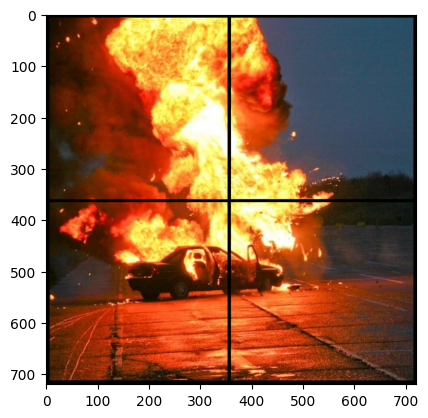

In [232]:
baca = cv.imread('Assets/Meledak.png')
boom = cv.cvtColor(baca, cv.COLOR_BGR2RGB)
plt.imshow(boom, cmap="gray")

Gambar Meledak.png dari folder Asssets dibaca dengan cv dengan fungsi imread() lalu dikonversi colormapnya jadi RGB karena secara default cv.imread() membaca gambar secara BGR. Gambar lalu ditampilkan dengan fungsi imshow pada library plt.

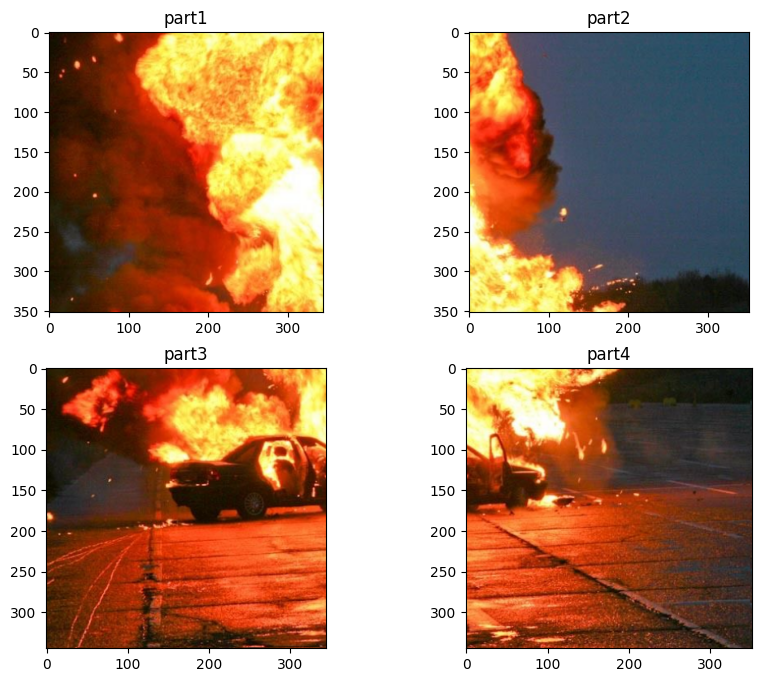

In [233]:
# slice
h, w, d = boom.shape
boom1 = boom[7:359, 7:352]
boom2 = boom[7:359, 363:715]
boom3 = boom[368:713, 7:352]
boom4 = boom[368:713, 363:715]

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.title("part1")
plt.imshow(boom1, cmap="gray")
plt.subplot(2,2,2)
plt.title("part2")
plt.imshow(boom2, cmap="gray")
plt.subplot(2,2,3)
plt.title("part3")
plt.imshow(boom3, cmap="gray")
plt.subplot(2,2,4)
plt.title("part4")
plt.imshow(boom4, cmap="gray")

Gambar boom lalu dipotong untuk mengambil bagian-bagian yang diperlukan dengan mengambil array pixelnya pada koordinat x dan y. Potongan-potongan yang diperlukan itu disimpan dalam boom1, boom2, boom2, dan boom4 lalu ditampilkan dengan fungsi imread pada library plt. 

Kode di bawah ini digunakan untuk mengetahui ukuran-ukuran setiap potongannya.

In [234]:
print(boom1.shape)
print(boom2.shape)
print(boom3.shape)
print(boom4.shape)

(352, 345, 3)
(352, 352, 3)
(345, 345, 3)
(345, 352, 3)


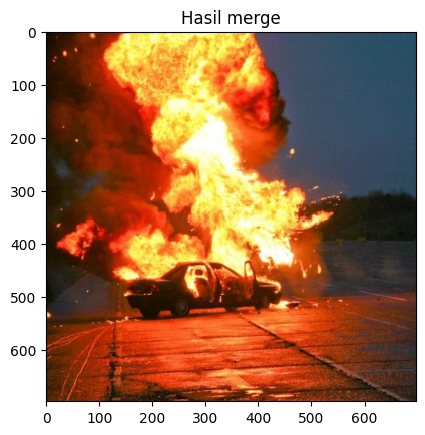

In [235]:
# gabung
atas = img.merge_image(boom1, boom2, 'H')
bawah = img.merge_image(boom3, boom4, 'H')

jadi = img.merge_image(atas, bawah, 'V')
# plt.imshow(atas, cmap="gray")
# plt.imshow(bawah, cmap="gray")
plt.title("Hasil merge")
plt.imshow(jadi, cmap="gray")

# MERGE

Kode di atas melakukan penggabungan semua potongan gambar menjadi 1. Langkah pertama yang dilakukan yaitu menggabungkan boom1 dan boom2 secara horizontal dengan memanggil fungsi pada library buatan manimg (kita bilang saja library img mulai sekarang) pada folder pcdlib yaitu fungsi merge_image() dan mengirim argumen 'H' untuk malakukan merge secara horizontal, hasilnya disimpan pada variabel atas. Langkah kedua yaitu menggabung boom3 dan boom4 secara horizontal dengan cara yang sama seperti pada boom1 dan boom2 dan hasilnya disimpan pada variabel bawah. Langkah ketiga, atas dan bawah digabungkan secara vertikal dengan memanggil fungsi yang sama pada library img namun mengirim argumen 'V' untuk melakukan merge secara vertikal lalu hasilnya disimpan pada variabel jadi. variabel jadi lalu ditampilkan dengan plt.imshow 

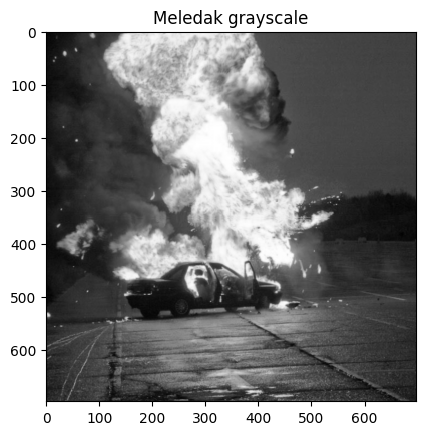

In [236]:
#  citra diubah menjadi grayscale
boom_gray = cv.cvtColor(jadi, cv.COLOR_RGB2GRAY)
plt.title("Meledak grayscale")
plt.imshow(boom_gray, cmap="gray")

citra jadi ini kemudian dikonversi colormapnya menjadi grayscale menggunakan library cv2 dengan fungsi cv.cvtColor dan mengirim argumen cv cv.COLOR_RGB2GRAY, hasilnya disimpan pada variabel boom_gray lalu ditampilkan dengan plt.imshow

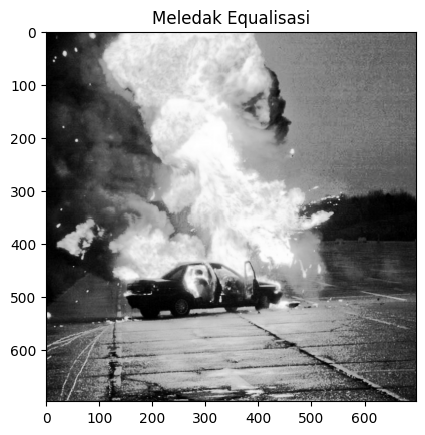

In [237]:
# proses equalization
boom_equal = lib.equalization_grayscale(boom_gray)
plt.title("Meledak Equalisasi")
plt.imshow(boom_equal, cmap="gray")


citra boom_gray kemudian di equalisasi agar intensitas pixelnya muncul secara merata dengan memanggil fungsi equalization_grayscale pada library buatan manhist (kita bilang saja library lib mulai sekarang) pada folder pcdlib. Hasilnya lalu disimpan pada variabel boom_equal dan ditampilkan dengan plt.imshow().

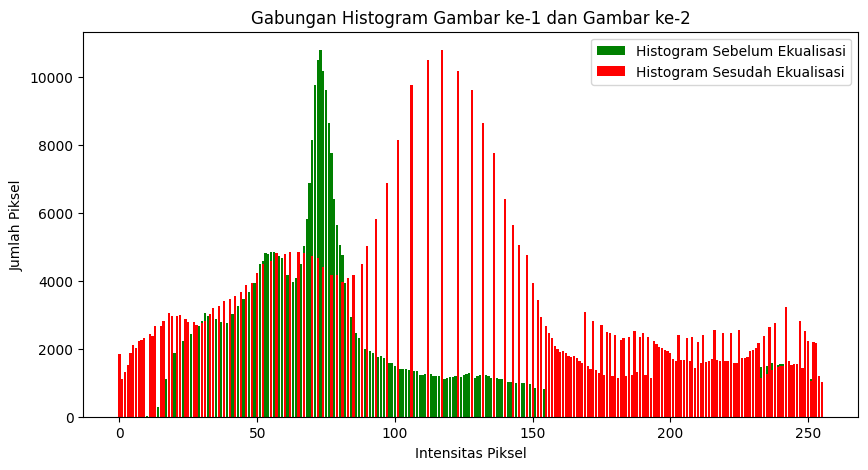

In [238]:
# tampilin histogram gabungan

histo1 = img.buat_hist(boom_gray)
histo2 = img.buat_hist(boom_equal)

lib.plot_histo_double("Gabungan Histogram Gambar ke-1 dan Gambar ke-2", histo1, "Histogram Sebelum Ekualisasi", "green", histo2, "Histogram Sesudah Ekualisasi", "red")

Data-data jumlah intesitas pada setiap pixel untuk gambar boom_gray (gambar yang belum di equalisasi) dan gambar boom_equal (gambar yang sudah diequalisasi) dihitung dengan memanggil fungsi buat_hist pada libarary img dan disimpan pada variabel histo1 dan histo2. Hasil pembacaan data-data tersebut kemudian ditampilkan pada diagram bar dengan memanggil fungsi plot_histo_double pada library lib yang akan menampilkan 2 buah histogram secara bertumpuk untuk melihat perbedaan antara gambar ke-1 dan gambar ke-2.

Pada histogran yang ditampilkan, dapat dilihat bahwa intensitas piksel pada histogram merah (after equal) tersebar rata dari intensitas 0 hingga 250an sedangkan intensitas pixel pada hostogram hijau tidak tersebar rata, terbukti pada intensitas 150-250 tidak terlihat jumlah pixel yang dimiliki sangat kontras dengan intensitas 0-150 yang muncul sangat sering pada citra.

Kesimpulannya, proses equalisasi dilakukan agar setiap pixel pada gambar dapat muncul dengan rata dan membuat gambar menjadi high contrass.

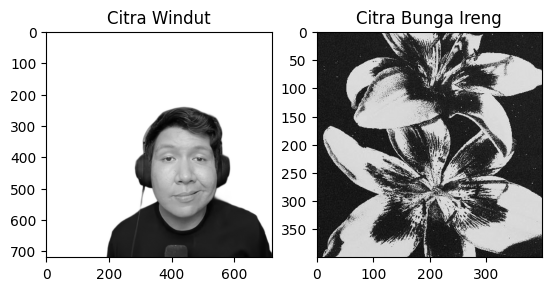

In [239]:
# Baca windut dan bunga
ambil = cv.imread('Assets/Windut.png')
windut = cv.cvtColor(ambil, cv.COLOR_BGR2GRAY)

take = cv.imread('Assets/Bunga.png')
bunga = cv.cvtColor(take, cv.COLOR_BGR2GRAY)


plt.subplot(1, 2, 1)
plt.title("Citra Windut")
plt.imshow(windut, cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Citra Bunga Ireng")
plt.imshow(bunga, cmap="gray")


Gambar Windut.png dan Bunga.png dari folder Asssets dibaca dengan cv dengan fungsi imread() lalu dikonversi colormapnya jadi gray karena secara default cv.imread() membaca gambar secara BGR. Gambar lalu ditampilkan dengan fungsi imshow pada library plt.

Kode di bawah ini menampilkan histogram awal pada gambar windut dan bunga dengan memanggil fungsi plot_histo_double pada library buatan lib

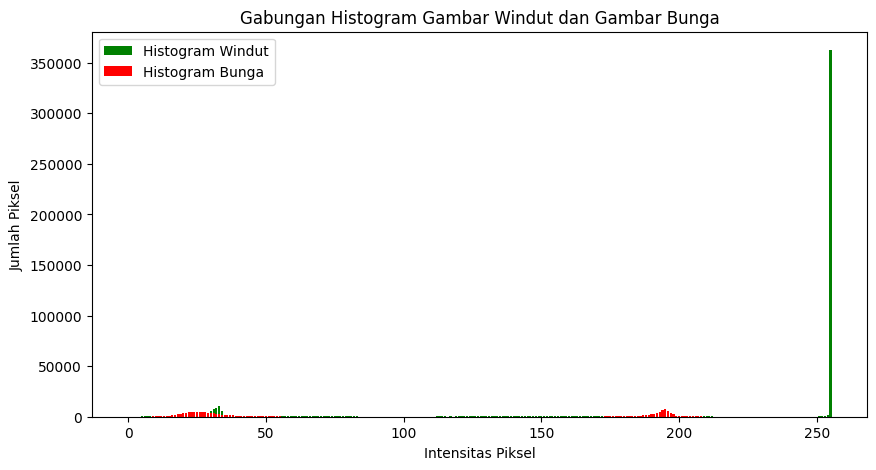

In [240]:
# Tampilkan histogram citra Windut dan citra bunga ireng.
histo_windut = img.buat_hist(windut)
histo_bunga = img.buat_hist(bunga)

lib.plot_histo_double("Gabungan Histogram Gambar Windut dan Gambar Bunga", histo_windut, "Histogram Windut", "green", histo_bunga, "Histogram Bunga", "red")

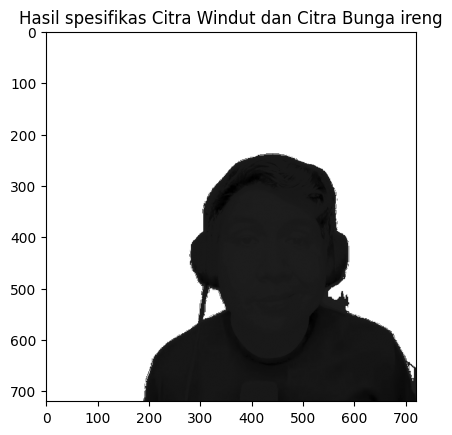

In [241]:
# spesifikasi  pada  citra  Windut  dengan  citra  bunga  ireng
windut_spesi = lib.specification_gray_to_gray(windut, bunga)
plt.title("Hasil spesifikas Citra Windut dan Citra Bunga ireng")
plt.imshow(windut_spesi, cmap="gray")

Gambar windut lalu dispesifikasi dengan target gambar bunga dengan memanggil fungsi specification_gray_to_gray() pada library lib dan hasilnya disimpan pada variabel windut_spsei.

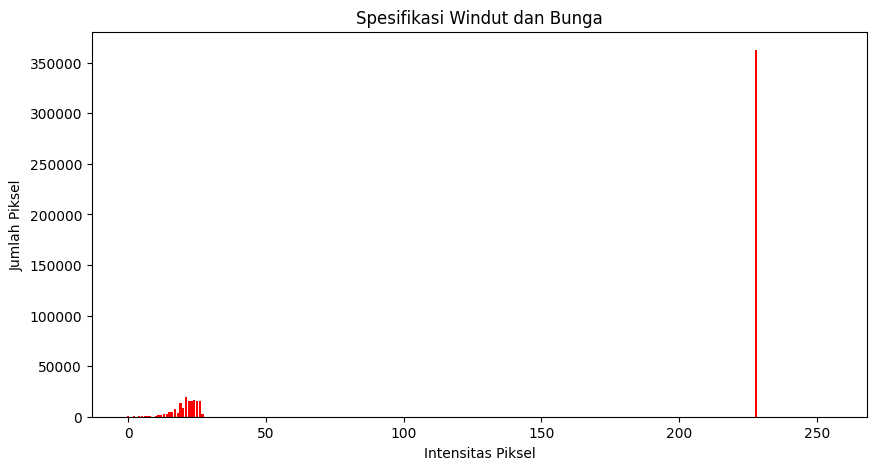

In [242]:
# histogram spesifikasi citra  Windut  dengan  citra  bunga  ireng
histo_Windut_spesi = img.buat_hist(windut_spesi)

lib.plot_histogram(histo_Windut_spesi, "Spesifikasi Windut dan Bunga", "red")

Data-data jumlah intesitas pada setiap pixel untuk gambar windut_spesi dihitung dengan memanggil fungsi buat_hist pada libarary img dan disimpan pada variabel histo_windut_spesi. Hasil pembacaan data-data tersebut kemudian ditampilkan pada diagram bar dengan memanggil fungsi plot_histogram pada library lib yang akan sebuah histogram dari data-data yang telah dibaca pada windut_spesi.

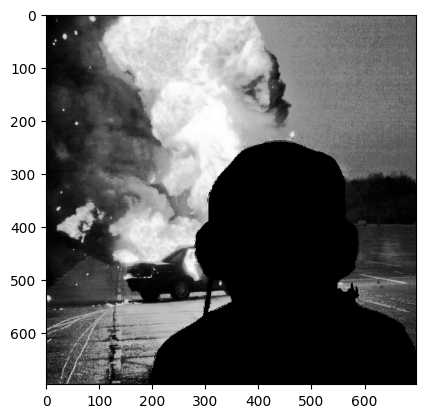

In [243]:
# cropping agar dimensinya sama
windut_resize = windut_spesi[0:boom_equal.shape[0], 0:boom_equal.shape[1]]
windut_mask = img.threshold(windut_resize)

# proses masking
masking = lib.masking_gray_to_gray(boom_equal, windut_mask)
plt.imshow(masking, cmap="gray")


Proses Masking dilakukan pada citra windut_spesi dan boom_equal. Sebelum dilakukan masking, ukuran kedua citra tersebut disamakan dengan mengambil nilai lebar dan tinggi minimum dari keduanya. Karena ukuran lebar dan tinggi boom_equal adalah minimumnya, makan citra windut_spesi di potong seukuran boom_equal dan hasilnya disimpan pada variabel windut_resize. Setalah ukuran keduanya sama, dilakukan proses traceholding pada windut_resize untuk menyiapkan mask yang tepat yaitu hitam putih dengan nilai batas traceholdnya itu 128, namun argumen batas tracehold tidak diberikan karena sudah diset nilai defaultnya yaitu 128 pada library buatan img. Setelah semuanya siap, proses masking pun dilakukan. Masking dilakukan dengan memanggil fungsi masking_gray_to_gray() pada libarary lib dan hasilnya disimpan pada variabel masking lalu ditampilkan dengan plt.imshow.

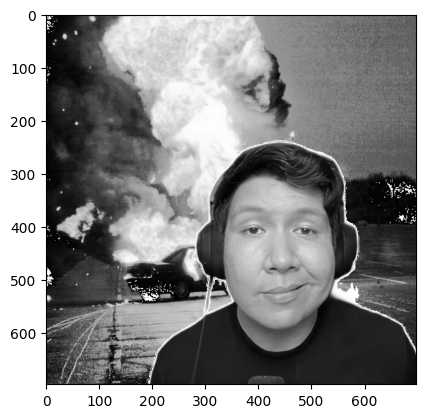

In [244]:
# penggabungan citra dengan menempelkan objek utama kebackground
akhir = masking + windut[0:697, 0:697]

plt.imshow(akhir, cmap="gray")

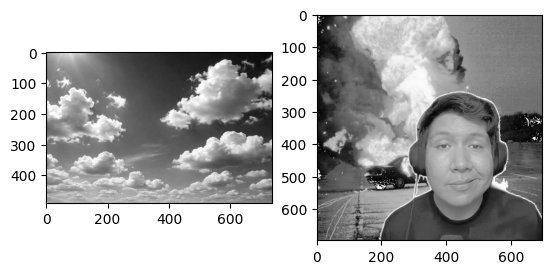

In [245]:
# spesifikasi akhir
taulah = cv.imread('Assets/Langit.png')
langit = cv.cvtColor(taulah, cv.COLOR_BGR2GRAY)

spe_akhir = lib.specification_gray_to_gray(akhir, langit)

plt.subplot(1, 2, 1)
plt.imshow(langit, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(spe_akhir, cmap="gray")


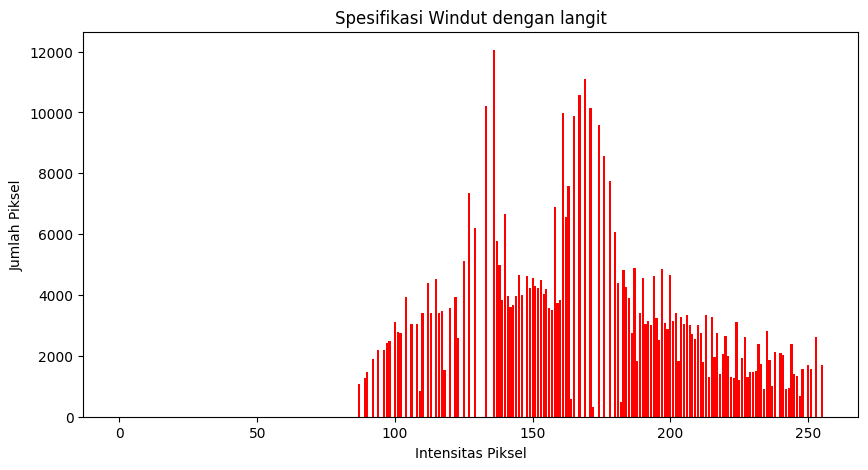

In [246]:
# Histogram spesifikasi akhir

histo_spe_akhir = img.buat_hist(spe_akhir)
lib.plot_histogram(histo_spe_akhir, "Spesifikasi Windut dengan langit", "red")

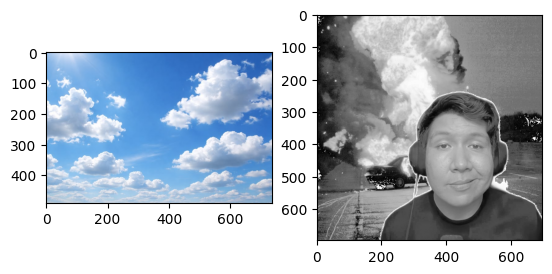

In [247]:
lagi = cv.imread('Assets/Langit.png')
langit_cerah = cv.cvtColor(taulah, cv.COLOR_BGR2RGB)

plt.subplot(1,2,1)
plt.imshow(langit_cerah, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(spe_akhir, cmap="gray")


Gambar Langit.png dari folder Asssets dibaca lagi dengan cv dengan fungsi imread() lalu dikonversi colormapnya jadi RGB karena secara default cv.imread() membaca gambar secara BGR dan simpan pada variabel langit_cerah. 

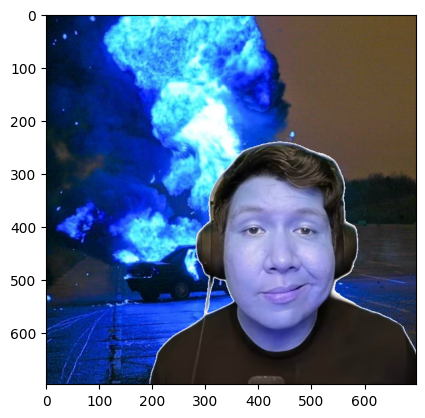

In [248]:
windut_color = cv.imread("Assets/Windut.png")

windut_mask = np.zeros_like(windut_color)
for i in range(windut_color.shape[0]):
    for j in range(windut_color.shape[1]):
        if windut[i, j] < 250:  # pakai grayscale sebagai mask
            windut_mask[i, j] = windut_color[i, j]

windut_mask = windut_mask[0:697, 0:697]
jadi = cv.cvtColor(jadi, cv.COLOR_RGB2BGR)

windut_last = np.zeros_like(windut_mask)
for i in range(windut_mask.shape[0]):
    for j in range(windut_mask.shape[1]):
        if windut_mask[i, j, 0] == 0 and windut_mask[i, j, 1] == 0 and windut_mask[i, j, 2] == 0:
            windut_last[i, j] = jadi[i, j]
        else:
            windut_last[i, j] = windut_mask[i, j]

plt.imshow(windut_last)


Gambar windut dibaca lagi tapi dengan colormap default yaitu BGR, biar warna merah itu dibaca jadi warna biru, habis itu kasih backround berwarna.

Pada gambar windut itu diperiksa apakah nilai grayscale suatu piksel kurang dari 250. Nilai tersebut dianggap sebagai bagian objek karena background putih biasanya memiliki nilai mendekati 255. Jika kondisi terpenuhi, maka piksel warna asli dari windut_color akan disalin ke windut_mask. Dengan cara ini, objek akan tetap terlihat sedangkan background berubah menjadi hitam. Teknik ini disebut threshold masking karena pemisahan objek dilakukan berdasarkan ambang nilai intensitas piksel.

Windut_mask ini kemudian di sesuaikan ukurannya dengan citra jadi, karena backgroundnya mau disesuaikan dengan citra jadi ini.

Berikutnya, citra jadi dikonversi menggunakan fungsi cv.cvtColor() dari format RGB ke BGR sesuai dengan citra windut_mask dan juga kita mau warna merah itu dibaca biru. Setelah itu dibuat lagi citra kosong bernama windut_last yang digunakan untuk menyimpan hasil akhir ganti background ini.

Proses ganti background dilakukan dengan memeriksa setiap piksel pada windut_mask. Jika suatu piksel bernilai hitam (0,0,0), maka dianggap area tersebut merupakan background sehingga piksel diambil dari citra jadi. Namun jika piksel bukan hitam, berarti area tersebut merupakan objek hasil masking sehingga piksel objek dipertahankan dan disalin ke windut_last. Dengan teknik ini, objek dari gambar Windut.png dapat ditempelkan ke background baru tanpa membawa background lama.

Terakhir, hasil ditampilkan menggunakan plt.imshow().